In [107]:
import torch    
import torch.nn as nn
import math

In [108]:
class Config:
    def __init__(self):
        self.vocab_size = 30522
        self.dim = 768
        self.n_heads = 12
        self.head_dim = self.dim // self.n_heads # 64
        self.n_layers = 6
        self.ffn_hidden = 3072 # 4 * dim
        self.max_position = 512 # maximum sequence length
        self.eps = 1e-12 # small number for LayerNorm
        self.n_classes = 2 # positive or negative sentiment

config = Config()
print(config.dim)
print(config.head_dim)

768
64


In [121]:
# Embedding layer : token embedding + positional embedding
class Embeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.word_embedding = nn.Embedding(config.vocab_size, config.dim)
        self.position_embedding = nn.Embedding(config.max_position, config.dim)
        self.layer_norm = nn.LayerNorm(config.dim, eps=config.eps)
    
    def forward(self, input_ids):
        word_embeds = self.word_embedding(input_ids)
        seq_len = input_ids.shape[1]
        position_ids = torch.arange(seq_len).unsqueeze(0) # (1, seq_len)
        position_embeds = self.position_embedding(position_ids)

        embeddings = word_embeds + position_embeds
        embeddings = self.layer_norm(embeddings)
        return embeddings

# # test
# embedding_layer = Embeddings(config)
# fake_input = torch.randint(0, config.vocab_size, (1, 10)) # (1, 10)
# print(fake_input)
# outputs = embedding_layer(fake_input)
# print(outputs.shape) # (1, 10, 768)

tensor([[29324,  8879,  6728, 20634,  8961,  6406,  3883, 11311, 21400, 29616]])
torch.Size([1, 10, 768])


In [124]:
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_heads
        self.head_dim = config.head_dim
        self.dim = config.dim

        # multi heads attention projections
        # process 12 heads together for efficiency, later split into 12 heads
        self.q_lin = nn.Linear(config.dim, config.dim) # process all heads together
        self.k_lin = nn.Linear(config.dim, config.dim)
        self.v_lin = nn.Linear(config.dim, config.dim)
        self.out_lin = nn.Linear(config.dim, config.dim)

        # layer norm
        self.attn_layer_norm = nn.LayerNorm(config.dim, eps=config.eps)
        self.ffn_layer_norm = nn.LayerNorm(config.dim, eps=config.eps)

        # feed forward network
        self.lin1 = nn.Linear(config.dim, config.ffn_hidden)
        self.lin2 = nn.Linear(config.ffn_hidden, config.dim)
    
    def forward(self, x):
        batch, seq_len, dim = x.shape

        # --- Multi-head self-attention ---

        # 1. project input to Q, K, V
        Q = self.q_lin(x) # (batch, seq_len, dim)
        K = self.k_lin(x)
        V = self.v_lin(x)

        # 2. split into 12 heads
        # from (1, 10, 768) to (1, 10, 12, 64) --> (1, 12, 10, 64)
        Q = Q.reshape(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2) # (batch, n_heads, seq_len, head_dim)
        K = K.reshape(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.reshape(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        # 3. attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        weights = torch.softmax(scores, dim=-1) # along columns

        # 4. apply weights to V to get context
        context = torch.matmul(weights, V) # (batch, n_heads, seq_len, head_dim)
        
        # 5. merge heads back
        # concatenate context from 12 heads: (1, 12, 10, 64) --> (1, 10, 12, 64) --> (1, 10, 768)
        context = context.transpose(1, 2).reshape(batch, seq_len, dim)

        # 6. final linear layer + residul + layer norm
        attn_output = self.out_lin(context)
        x = self.attn_layer_norm(x + attn_output)


        # --- Feed Forward Network ---
        ffn_output = self.lin1(x)
        ffn_output = torch.nn.functional.gelu(ffn_output)
        ffn_output = self.lin2(ffn_output)
        x = self.ffn_layer_norm(x + ffn_output)

        return x, weights
    

# # Test
# block = AttentionBlock(config)
# fake_embedding = torch.rand(2, 10, 768) # (batch, seq_len, dim)
# output, weights = block(fake_embedding)
# print(output.shape) # (2, 10, 768)
# print(weights.shape) # (2, 12, 10, 10)



torch.Size([2, 10, 768])
torch.Size([2, 12, 10, 10])


In [150]:
# Encoder
# stack 6 attention blocks in sequence
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.ModuleList([AttentionBlock(config) for _ in range(config.n_layers)])
    
    def forward(self, x):
        all_weights = []
        for layer in self.layers:
            x, weights = layer(x)
            all_weights.append(weights)
        return x, all_weights

# Test
encoder = Encoder(config)
fake_embedding = torch.rand(2, 10, 768) # (batch, seq_len, dim)
output, weights = encoder(fake_embedding)
print(output.shape) # (2, 10, 768)

torch.Size([2, 10, 768])


In [151]:
# FULL MODEL
class Transformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = Embeddings(config)
        self.encoder = Encoder(config)
        self.pre_classifier = nn.Linear(config.dim, config.dim)
        self.classifier = nn.Linear(config.dim, config.n_classes)
    
    def forward(self, input_ids):
        # stage 1: token ids --> embeddings
        x = self.embeddings(input_ids) # (batch, seq_len, dim)

        # stage 2: run through all 6 attention blocks through the encoder
        x, all_weights = self.encoder(x) # (batch, seq_len, dim)

        # stage 3 : pooling - grab only the [CLS] token representation (first token)
        x = x[:, 0, :] # (batch, dim)

        # stage 4 : classify
        x = self.pre_classifier(x)
        x = torch.nn.functional.gelu(x)
        logits = self.classifier(x) # (batch, n_classes)

        return logits, all_weights

# Test
model = Transformer(config)
fake_input = torch.randint(0, config.vocab_size, (2, 10))
logits, all_weights = model(fake_input)
print(logits.shape) # (2, 2) - batch size, n_classes

torch.Size([2, 2])


In [138]:
# Test the untrained model on a sample sentence
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sentence = "I love this movie!"
tokes = tokenizer(sentence, return_tensors="pt")

print(tokes['input_ids'])

tensor([[ 101, 1045, 2293, 2023, 3185,  999,  102]])


In [139]:
model = Transformer(config)
model.eval() # turn off training mode

with torch.no_grad(): # do not need gradients for inference
    logits = model(tokes['input_ids'])

print(logits)
print(logits.shape) # (1, 2) - batch size, n_classes

tensor([[-0.0259,  0.0645]])
torch.Size([1, 2])


In [140]:
probs = torch.softmax(logits, dim = -1)
print("P(negative): {:.1f}%".format(probs[0][0].item() * 100))                                                                 
print("P(positive): {:.1f}%".format(probs[0][1].item() * 100))

# will give random output, since the model is not trained.

P(negative): 47.7%
P(positive): 52.3%


In [141]:
sentences = [
      "This movie was absolutely fantastic.",                                                                                    
      "I hated every minute of it.",
      "The acting was okay but the plot was boring.",                                                                            
]

for s in sentences:
    tokens = tokenizer(s, return_tensors="pt")
    with torch.no_grad():
        logits = model(tokens['input_ids'])
    probs = torch.softmax(logits, dim = -1)
    print(f"Sentence: {s}")
    print(f"  P(negative): {probs[0][0].item()*100:.1f}%  P(positive): {probs[0][1].item()*100:.1f}%")
    print()



Sentence: This movie was absolutely fantastic.
  P(negative): 45.9%  P(positive): 54.1%

Sentence: I hated every minute of it.
  P(negative): 46.3%  P(positive): 53.7%

Sentence: The acting was okay but the plot was boring.
  P(negative): 42.3%  P(positive): 57.7%



In [142]:
# Test with with trained weights for distilbert: its name is distilbert.pt
state_dict = torch.load('distilbert.pt', map_location='cpu')
print(list(state_dict.keys())[:10])


['embeddings.word_embeddings.weight', 'embeddings.position_embeddings.weight', 'embeddings.LayerNorm.weight', 'embeddings.LayerNorm.bias', 'attention_layers.0.q_lin.weight', 'attention_layers.0.q_lin.bias', 'attention_layers.0.k_lin.weight', 'attention_layers.0.k_lin.bias', 'attention_layers.0.v_lin.weight', 'attention_layers.0.v_lin.bias']


In [144]:

# compare the key names in our model and in the state dict
print("=== YOUR MODEL KEYS ===")
for key in model.state_dict().keys():                                                                                          
    print(key)  
                                                                                                                                 
print("\n=== PRETRAINED KEYS ===")
for key in state_dict.keys():                                                                                                  
    print(key)

=== YOUR MODEL KEYS ===
embeddings.word_embedding.weight
embeddings.position_embedding.weight
embeddings.layer_norm.weight
embeddings.layer_norm.bias
encoder.layers.0.q_lin.weight
encoder.layers.0.q_lin.bias
encoder.layers.0.k_lin.weight
encoder.layers.0.k_lin.bias
encoder.layers.0.v_lin.weight
encoder.layers.0.v_lin.bias
encoder.layers.0.out_lin.weight
encoder.layers.0.out_lin.bias
encoder.layers.0.attn_layer_norm.weight
encoder.layers.0.attn_layer_norm.bias
encoder.layers.0.ffn_layer_norm.weight
encoder.layers.0.ffn_layer_norm.bias
encoder.layers.0.lin1.weight
encoder.layers.0.lin1.bias
encoder.layers.0.lin2.weight
encoder.layers.0.lin2.bias
encoder.layers.1.q_lin.weight
encoder.layers.1.q_lin.bias
encoder.layers.1.k_lin.weight
encoder.layers.1.k_lin.bias
encoder.layers.1.v_lin.weight
encoder.layers.1.v_lin.bias
encoder.layers.1.out_lin.weight
encoder.layers.1.out_lin.bias
encoder.layers.1.attn_layer_norm.weight
encoder.layers.1.attn_layer_norm.bias
encoder.layers.1.ffn_layer_norm.we

In [145]:
# remap the keys in the state dict to match our model's keys
def remap_keys(pretrained_state_dict):                                                                                         
    new_state_dict = {}
    for key, value in pretrained_state_dict.items():
        new_key = key
        # fix embedding names                                                                                                  
        new_key = new_key.replace('embeddings.word_embeddings.',   'embeddings.word_embedding.')
        new_key = new_key.replace('embeddings.position_embeddings.', 'embeddings.position_embedding.')                         
        new_key = new_key.replace('embeddings.LayerNorm.',         'embeddings.layer_norm.')
        # fix encoder layer names                                                                                              
        new_key = new_key.replace('attention_layers.',             'encoder.layers.')
        # fix layer norm names inside each block                                                                               
        new_key = new_key.replace('.sa_layer_norm.',               '.attn_layer_norm.')
        new_key = new_key.replace('.output_layer_norm.',           '.ffn_layer_norm.')                                         
        new_state_dict[new_key] = value
    return new_state_dict

remapped = remap_keys(state_dict)

# test if can load it
model.load_state_dict(remapped)
model.eval()


Transformer(
  (embeddings): Embeddings(
    (word_embedding): Embedding(30522, 768)
    (position_embedding): Embedding(512, 768)
    (layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x AttentionBlock(
        (q_lin): Linear(in_features=768, out_features=768, bias=True)
        (k_lin): Linear(in_features=768, out_features=768, bias=True)
        (v_lin): Linear(in_features=768, out_features=768, bias=True)
        (out_lin): Linear(in_features=768, out_features=768, bias=True)
        (attn_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (lin1): Linear(in_features=768, out_features=3072, bias=True)
        (lin2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
  )
  (pre_classifier): Linear(in_features=768, out_features=768, bias=True)
  (classifier): Linear(in_features=768

In [146]:
your_keys = set(model.state_dict().keys())
pretrained_keys = set(remapped.keys())

missing_keys = your_keys - pretrained_keys
extra_keys = pretrained_keys - your_keys

print("Missing keys in pretrained model:", missing_keys)
print("Extra keys in pretrained model:", extra_keys)

Missing keys in pretrained model: set()
Extra keys in pretrained model: set()


In [149]:
# test model.load_state_dict(remapped)
model.load_state_dict(remapped)
model.eval()

sentences = [
    "This movie was absolutely fantastic.",
    "I hated every minute of it.",                                                                                             
    "The acting was okay but the plot was boring.",
]

for s in sentences:
    tokens = tokenizer(s, return_tensors="pt")
    with torch.no_grad():
        logits = model(tokens['input_ids'])                                                                                    
    probs = torch.softmax(logits, dim=-1)
    print(f"'{s}'")                                                                                                            
    print(f"  P(negative): {probs[0][0].item()*100:.1f}%  P(positive): {probs[0][1].item()*100:.1f}%")
    print()

'This movie was absolutely fantastic.'
  P(negative): 0.0%  P(positive): 100.0%

'I hated every minute of it.'
  P(negative): 99.9%  P(positive): 0.1%

'The acting was okay but the plot was boring.'
  P(negative): 99.9%  P(positive): 0.1%



In [ ]:
model.load_state_dict(remapped)
model.eval()

sentence = "This movie was absolutely fantastic." 
tokens = tokenizer(sentence, return_tensors="pt")
token_words = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0].tolist())

with torch.no_grad():
    logits, all_weights = model(tokens['input_ids'])

print("Number of layers:", len(all_weights))
print(" Weight shape per layer :", all_weights[0].shape)
print("Tokens:", token_words)

Number of layers: 6
 Weight shape per layer : torch.Size([1, 12, 8, 8])
Tokens: ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', '.', '[SEP]']


/home/jtao/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


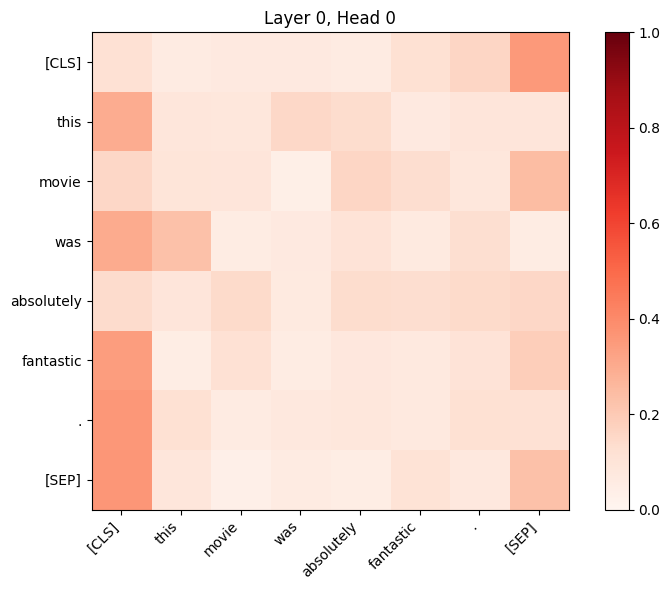

In [153]:
# plot one layer, one head
import matplotlib.pyplot as plt

layer_idx = 0   # first layer                                                                                                  
head_idx = 0    # first head

# extract the attention weights matrix for this layer and head
# all_weights is []
layer_weight = all_weights[layer_idx] # (batch, n_heads, seq_len, seq_len)
head_weight = layer_weight[0, head_idx] # (seq_len, seq_len)

fig, ax = plt.subplots(figsize=(8, 6))                                                                                         
im = ax.imshow(head_weight, cmap='Reds', vmin=0, vmax=1)

ax.set_xticks(range(len(token_words)))                                                                                         
ax.set_xticklabels(token_words, rotation=45, ha='right')
ax.set_yticks(range(len(token_words)))                                                                                         
ax.set_yticklabels(token_words)
                                                                                                                                
ax.set_title(f'Layer {layer_idx}, Head {head_idx}')
plt.colorbar(im)                                                                                                               
plt.tight_layout()
plt.show() 